In [1]:
import os 
results_path = os.path.join(os.getcwd(), "results")
paths = [os.path.join(results_path, x) for x in os.listdir(results_path)]
paths

['/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_shapes3d_model_cnn_rep_0',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_3',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_0',
 '/Users/miguelmartins/Projects/csi-robustness/results/log_id.txt',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_shapes3d_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/.DS_Store',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_geom_dsprites_model_mlp_rep_0',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep

In [27]:
def get_identifiability(df):
  return  (df["shape"] + df["posX"] + df["posY"]) / 3

def plot_train(dfs, idx=0):
    df_val, df_adv = dfs[idx]
  
    plt.figure(figsize=(12, 8))
    
    
    # Plot for df_val
    #plt.plot(df_val['epoch'], df_val['val_acc'], label='Accuracy', color='b', marker='o', markersize=8, linewidth=2)
    plt.plot(df_val['epoch'], df_val['shape'], label='Cat. id.', color='b', marker='o', markersize=8, linewidth=2)
    plt.plot(df_val['epoch'], get_identifiability(df_val), label='Identifiability', color='b', linestyle='--', marker='o', markersize=8, linewidth=2)

    # Plot for df_adv
    #plt.plot(df_adv['epoch'], df_adv['adv_acc'], label='Accuracy (noisy)', color='r', marker='s', markersize=8, linewidth=2)
    plt.plot(df_adv['epoch'], df_adv['shape'], label='Cat. id. (noisy)', color='r',marker='o', markersize=8, linewidth=2)
    plt.plot(df_adv['epoch'], get_identifiability(df_adv), label='Identifiability (noisy)', color='r', linestyle='--', marker='s', markersize=8, linewidth=2)
    
    
    # Title and labels with better formatting
    plt.title('Uncertainty priciple between identifiability-accuracy (mcc)', fontsize=20, fontweight='bold')
    plt.xlabel('Epoch', fontsize=18)
    plt.ylabel('Score', fontsize=18)
    
    # Adjust legend and grid
    plt.legend(fontsize=18, loc='best', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # Tight layout for better spacing
    plt.tight_layout()
    
    plt.show()

In [28]:
paths = ['/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/supervised_aug_none_dsprites_model_cnn_rep_3',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_2',
 '/Users/miguelmartins/Projects/csi-robustness/results/supervised_aug_none_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_1']

In [2]:
import re
import pandas as pd

import re
import pandas as pd
def parse_logs(log_path):
    
    with open(log_path, "r") as f:
        text = f.read()
    
    # Regexes for the lines we care about
    coord_re = re.compile(r"^Coordinate\s+(\d+)\s+(\w+)\s+([-\d\.eE+]+)")
    val_re   = re.compile(r"^val\s+Epoch\s+(\d+)\s+Loss\s+([-\d\.eE+]+)\s+val_acc\s+([-\d\.eE+]+)")
    adv_re   = re.compile(r"^adv\s+Epoch\s+(\d+)\s+Loss\s+([-\d\.eE+]+)\s+adv_acc\s+([-\d\.eE+]+)")
    
    rows_val = []
    rows_adv = []
    coords = {}   # holds shape/scale/orientation/posX/posY before each val/adv line
    
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
    
        # Coordinate lines
        m = coord_re.match(line)
        if m:
            idx, name, value = m.groups()
            coords[name] = float(value)
            continue
    
        # Validation block
        m = val_re.match(line)
        if m:
            epoch, loss, acc = m.groups()
            row = {
                "epoch": int(epoch),
                "loss": float(loss),
                "val_acc": float(acc),
            }
            row.update(coords)        # add shape/scale/orientation/posX/posY
            rows_val.append(row)
            coords = {}               # reset for next block
            continue
    
        # Adversarial block
        m = adv_re.match(line)
        if m:
            epoch, loss, acc = m.groups()
            row = {
                "epoch": int(epoch),
                "loss": float(loss),
                "adv_acc": float(acc),
            }
            row.update(coords)
            rows_adv.append(row)
            coords = {}
            continue
    
    # Build the two DataFrames
    df_val = pd.DataFrame(rows_val)
    df_adv = pd.DataFrame(rows_adv)
    
    return df_val, df_adv


In [3]:
dir_ = '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_1/'
 # <-- change if needed

df_val, df_adv = parse_logs(os.path.join(dir_, "log_probe.txt"))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_1/log_probe.txt'

In [31]:
df_val, df_adv

(    epoch      loss   val_acc     shape     scale  orientation      posX  \
 0       0  0.902642  0.797725  0.866367  0.870761     0.129732  0.610033   
 1      10  0.320834  0.906793  0.866367  0.870761     0.129732  0.610033   
 2      20  0.229669  0.932296  0.866367  0.870761     0.129732  0.610033   
 3      30  0.184511  0.944982  0.866367  0.870761     0.129732  0.610033   
 4      40  0.157140  0.952876  0.866367  0.870761     0.129732  0.610033   
 5      50  0.139019  0.957759  0.866367  0.870761     0.129732  0.610033   
 6      60  0.126350  0.961372  0.866367  0.870761     0.129732  0.610033   
 7      70  0.117214  0.963772  0.866367  0.870761     0.129732  0.610033   
 8      80  0.110186  0.965861  0.866367  0.870761     0.129732  0.610033   
 9      90  0.104714  0.967416  0.866367  0.870761     0.129732  0.610033   
 10    100  0.000000  0.968379  0.866367  0.870761     0.129732  0.610033   
 
         posY  
 0   0.719916  
 1   0.719916  
 2   0.719916  
 3   0.719

In [32]:
vals, advs = [], []
paths = [
    '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_1',
    '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_1',
     '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_1',
 '/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_1'
 ]

dfs = []
for i, p in enumerate(paths):
    print(p)
    log_path = os.path.join(p, "log_probe.txt")  
    df_val, df_adv = parse_logs(log_path)
    dfs.append([df_val, df_adv])
    vals.append(df_val.iloc[-1])
    advs.append(df_adv.iloc[-1])

/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_1


/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep_1


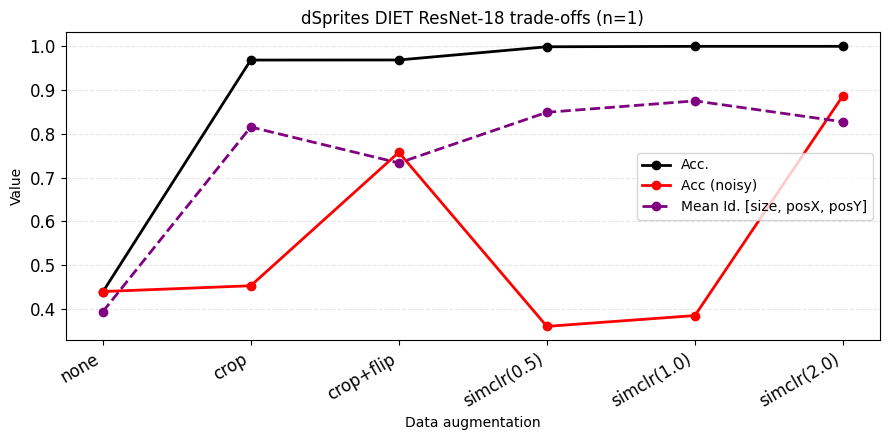

In [42]:
import matplotlib.pyplot as plt
vals, advs = [], []
rep = 1
paths = [
    f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_{rep}',
    f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_{rep}',
     f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_{rep}',
 f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_{rep}',
    f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_{rep}',
        f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep_{rep}',

 ]
dfs = []
for i, p in enumerate(paths):
    print(p)
    log_path = os.path.join(p, "log_probe.txt")  
    df_val, df_adv = parse_logs(log_path)
    dfs.append([df_val, df_adv])
    vals.append(df_val.iloc[-1])
    advs.append(df_adv.iloc[-1])
# Labels for the different configurations
labels = ["none", "crop", "crop+flip",
          "simclr(0.5)", "simclr(1.0)", "simclr(2.0)"]

# Indices for x-axis
x = range(len(labels))

# Compute IDs
val_id = [(v['scale'] + v['posX'] + v['posY']) / 3 for v in vals]
adv_id = [(a['scale'] + a['posX'] + a['posY']) / 3 for a in advs]

# Accuracies
val_acc = [v['val_acc'] for v in vals]
adv_acc = [a['adv_acc'] for a in advs]

plt.figure(figsize=(9, 4.5))

# Main curves
plt.plot(x, val_acc, color="black", marker="o", linewidth=2, label="Acc.")
plt.plot(x, adv_acc, color="red", marker="o", linewidth=2, label="Acc (noisy)")
plt.plot(x, val_id, color="purple", marker="o", linestyle='--', linewidth=2,
         label=r"Mean Id. [size, posX, posY]")

# X-ticks with your labels (bigger font)
plt.xticks(x, labels, rotation=30, ha="right", fontsize=12)

# (Optional) Make y-ticks match
plt.yticks(fontsize=12)

# Labels & title
plt.xlabel("Data augmentation")
plt.ylabel("Value")
plt.title("dSprites DIET ResNet-18 trade-offs (n=1)")

# Add a light grid for readability
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()


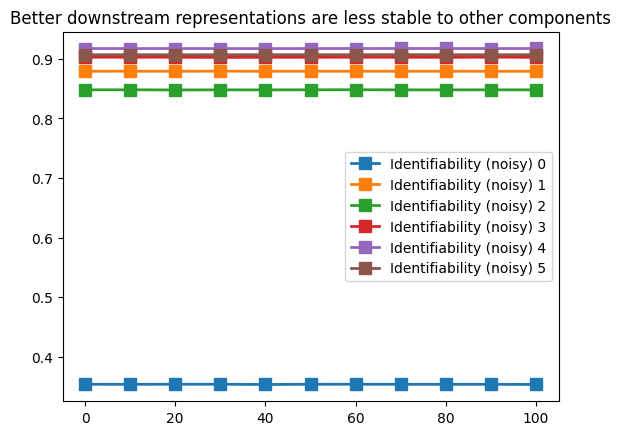

In [34]:
for i in range(len(dfs)):
    df_val, df_adv = dfs[i]
    plt.plot(df_adv['epoch'], get_identifiability(df_adv), label=f'Identifiability (noisy) {i}',  marker='s', markersize=8, linewidth=2)
plt.legend()
plt.title("Better downstream representations are less stable to other components")
plt.show()

/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_1
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep_1


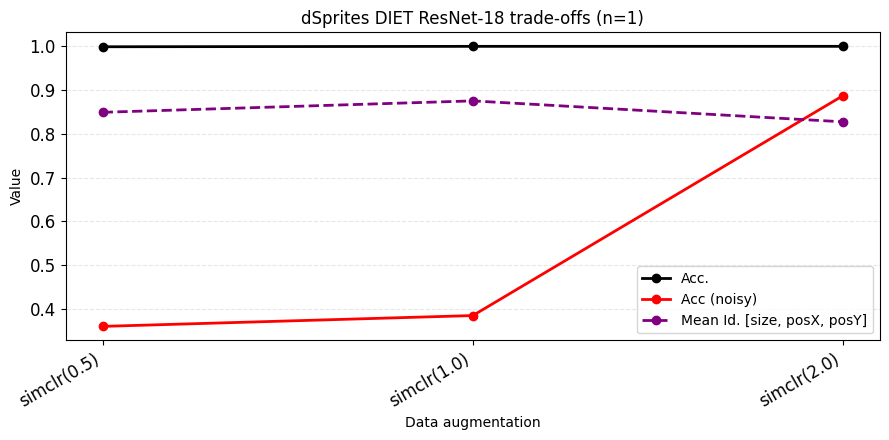

In [43]:
import matplotlib.pyplot as plt
vals, advs = [], []
rep = 1
paths = [
 f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_{rep}',
    f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_{rep}',
        f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep_{rep}',
 ]
dfs = []
for i, p in enumerate(paths):
    print(p)
    log_path = os.path.join(p, "log_probe.txt")  
    df_val, df_adv = parse_logs(log_path)
    dfs.append([df_val, df_adv])
    vals.append(df_val.iloc[-1])
    advs.append(df_adv.iloc[-1])
# Labels for the different configurations
labels = [
          "simclr(0.5)", "simclr(1.0)", "simclr(2.0)"]

# Indices for x-axis
x = range(len(labels))

# Compute IDs
val_id = [(v['scale'] + v['posX'] + v['posY']) / 3 for v in vals]
adv_id = [(a['scale'] + a['posX'] + a['posY']) / 3 for a in advs]

# Accuracies
val_acc = [v['val_acc'] for v in vals]
adv_acc = [a['adv_acc'] for a in advs]

plt.figure(figsize=(9, 4.5))

# Main curves
plt.plot(x, val_acc, color="black", marker="o", linewidth=2, label="Acc.")
plt.plot(x, adv_acc, color="red", marker="o", linewidth=2, label="Acc (noisy)")
plt.plot(x, val_id, color="purple", marker="o", linestyle='--', linewidth=2,
         label=r"Mean Id. [size, posX, posY]")

# X-ticks with your labels (bigger font)
plt.xticks(x, labels, rotation=30, ha="right", fontsize=12)

# (Optional) Make y-ticks match
plt.yticks(fontsize=12)

# Labels & title
plt.xlabel("Data augmentation")
plt.ylabel("Value")
plt.title("dSprites DIET ResNet-18 trade-offs (n=1)")

# Add a light grid for readability
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()


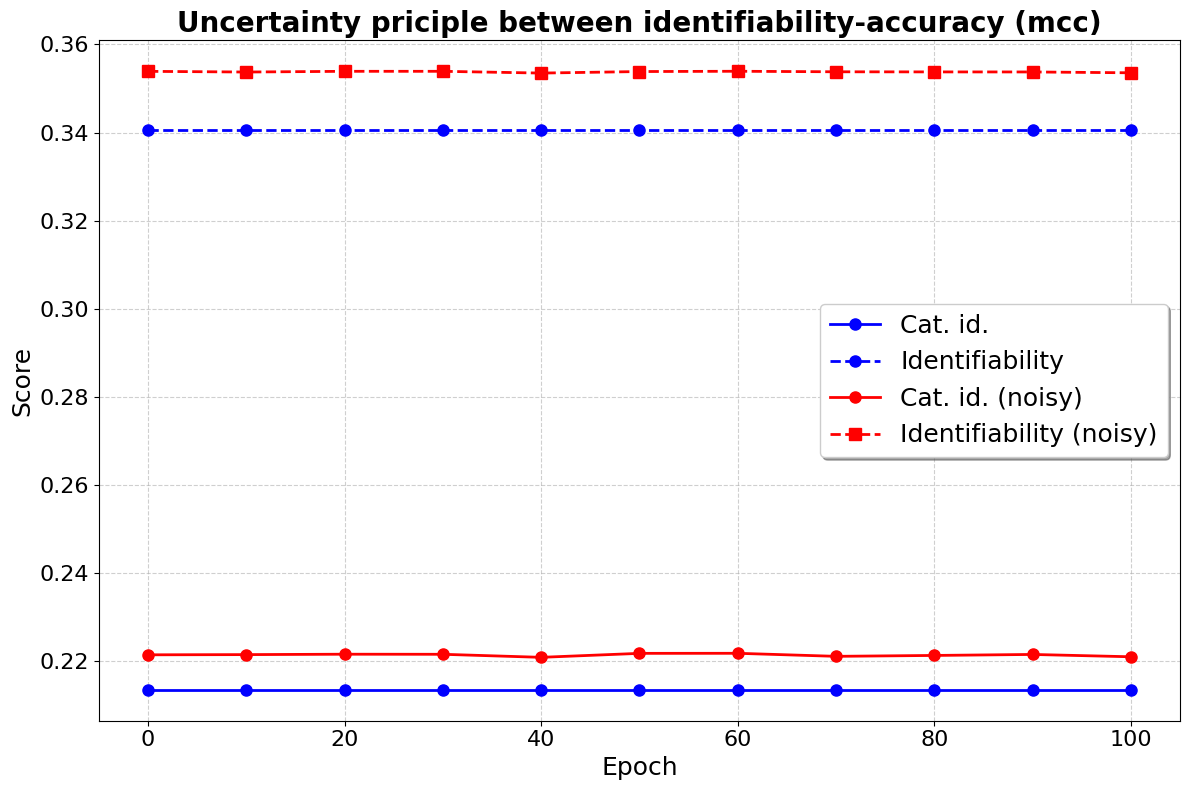

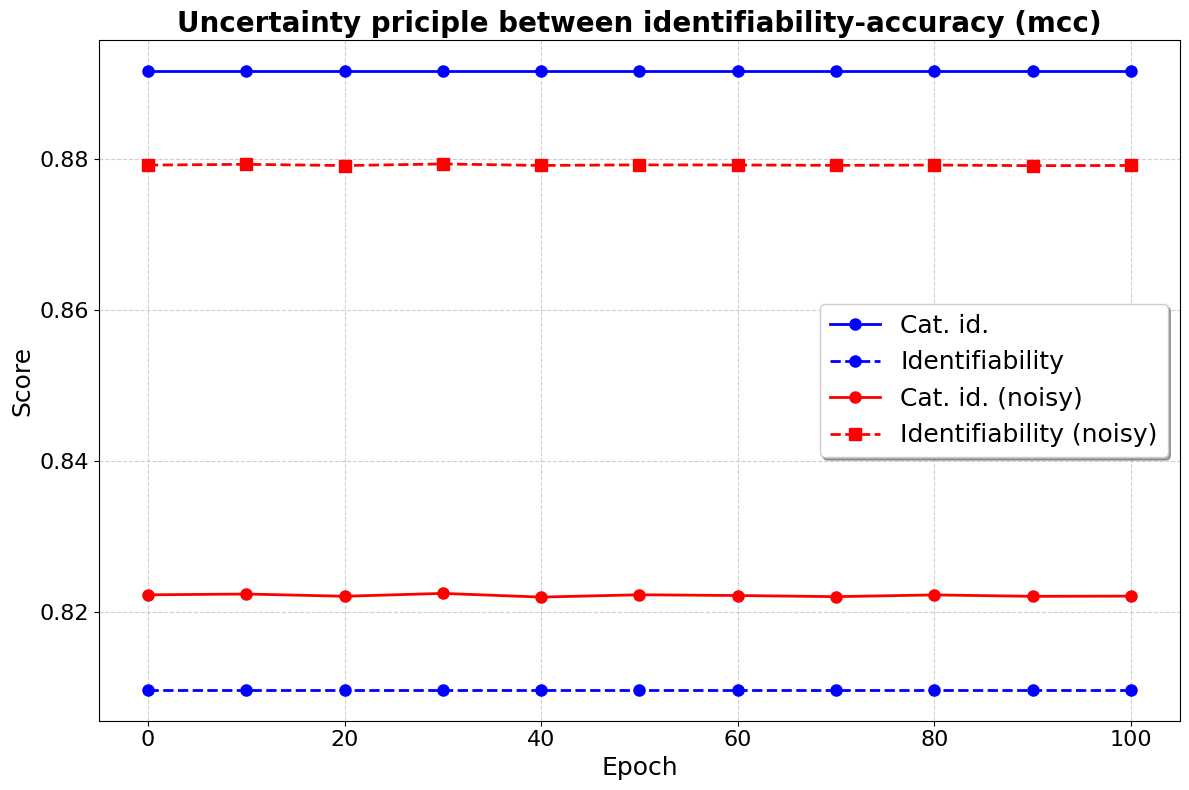

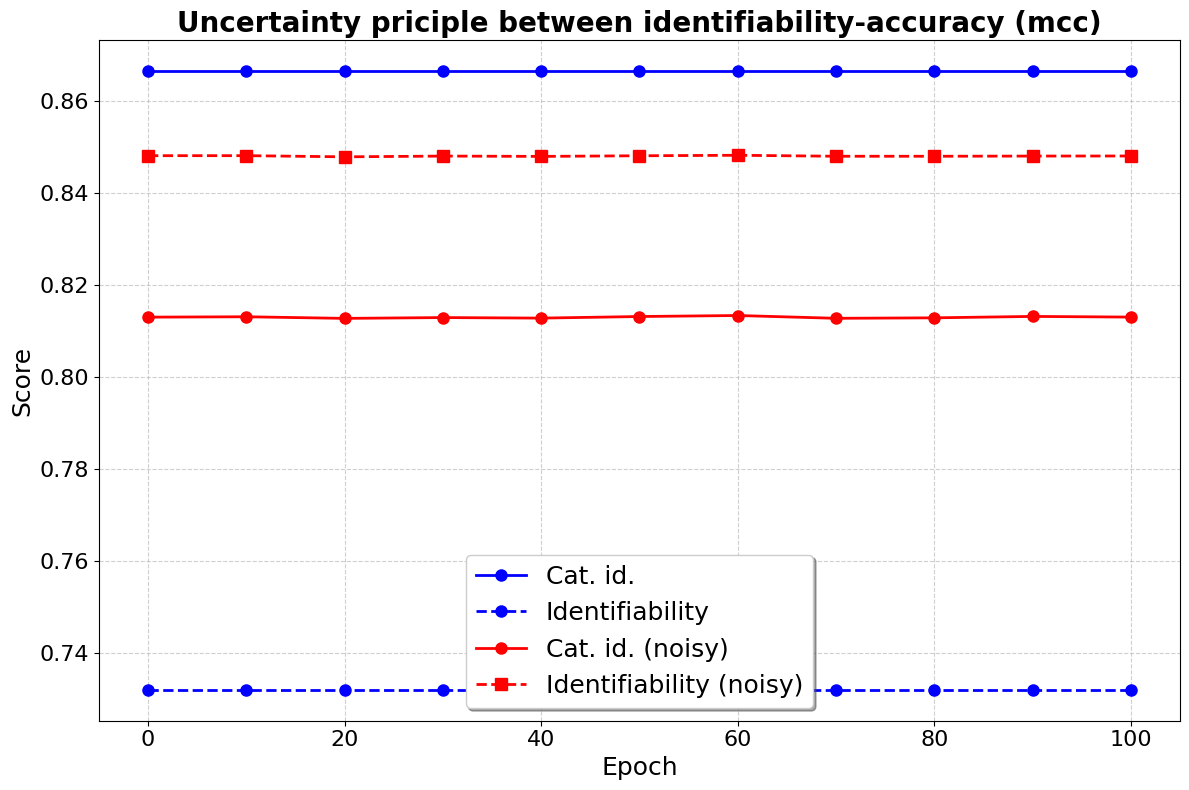

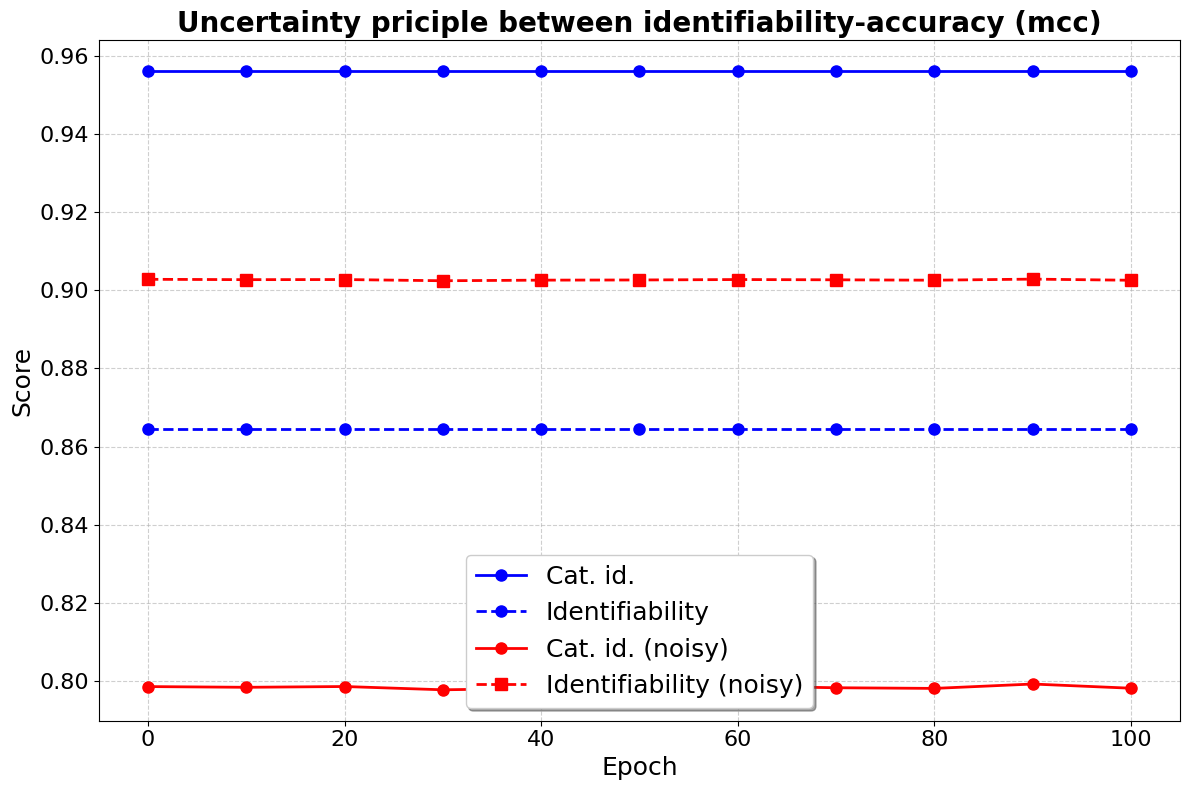

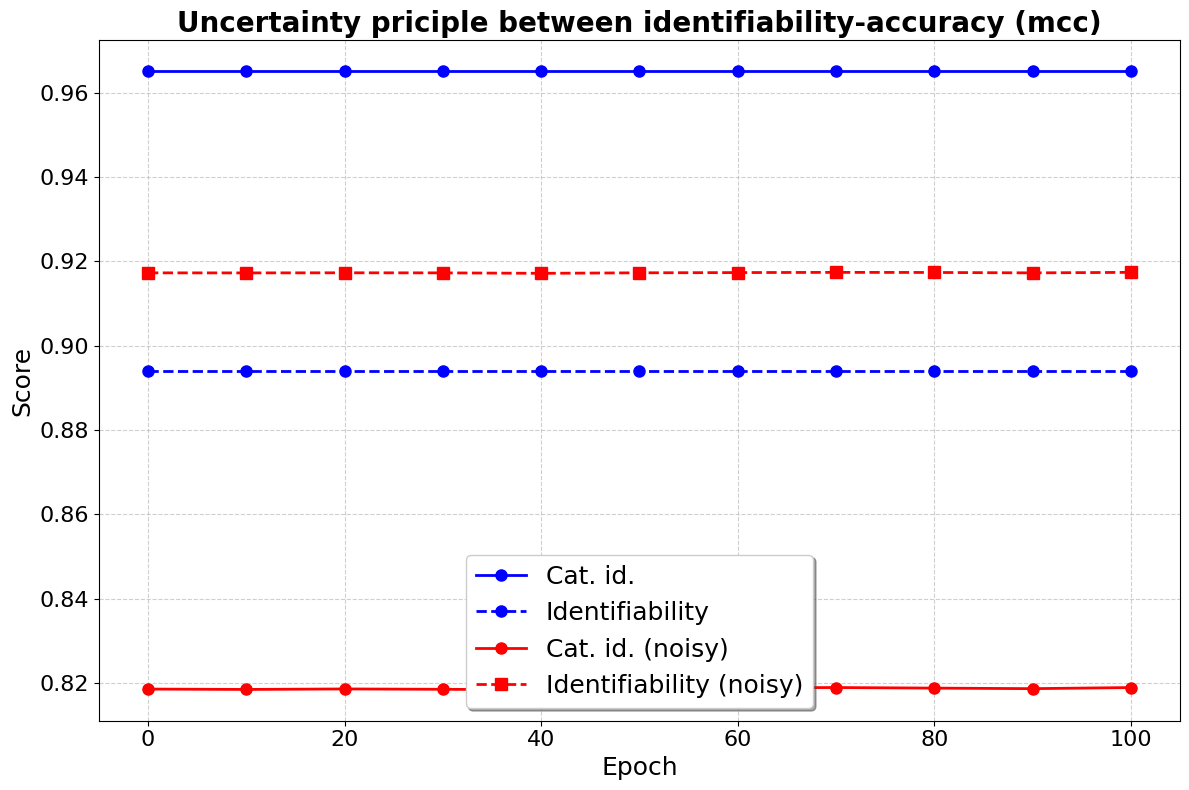

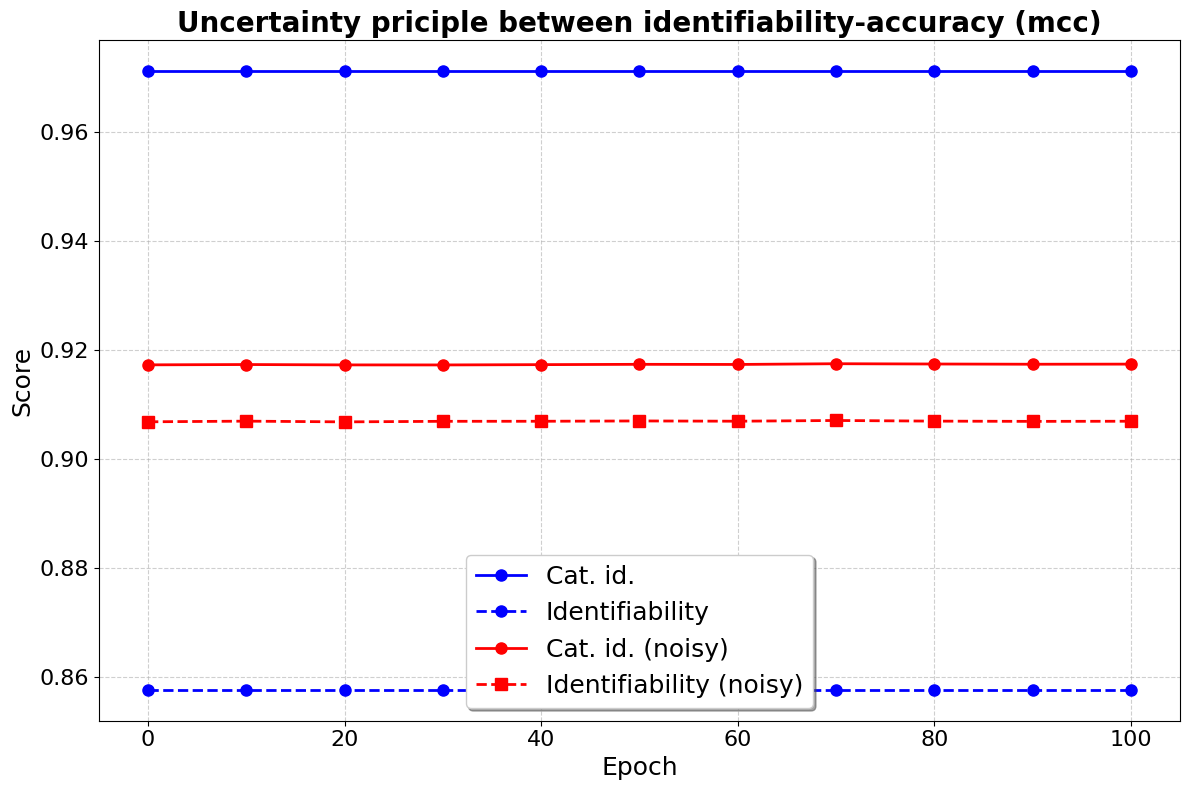

In [35]:
for i in range(len(dfs)):
    plot_train(dfs, idx=i)


/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_2
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_2
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_2
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_2
/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_2


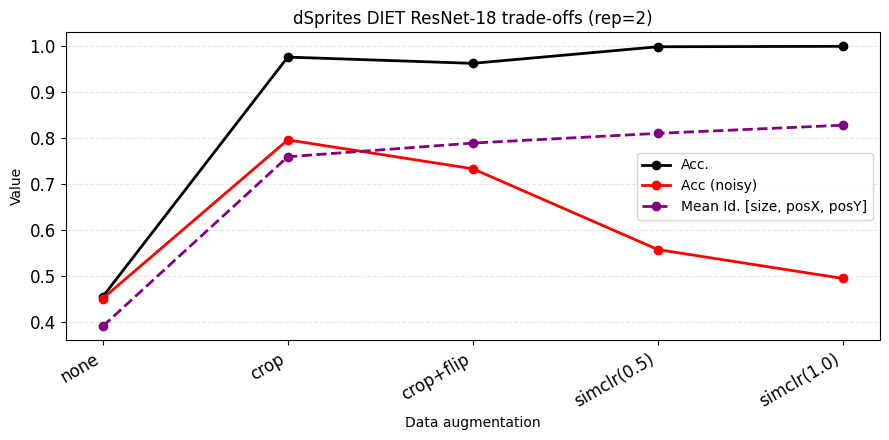

In [36]:
import matplotlib.pyplot as plt
vals, advs = [], []
rep = 2
paths = [
    f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_none_dsprites_model_cnn_rep_{rep}',
    f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_crop_dsprites_model_cnn_rep_{rep}',
     f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_sup_dsprites_model_cnn_rep_{rep}',
 f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr_dsprites_model_cnn_rep_{rep}',
    f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr2_dsprites_model_cnn_rep_{rep}',
    #f'/Users/miguelmartins/Projects/csi-robustness/results/diet_aug_simclr3_dsprites_model_cnn_rep_{rep}',

 ]
dfs = []
for i, p in enumerate(paths):
    print(p)
    log_path = os.path.join(p, "log_probe.txt")  
    df_val, df_adv = parse_logs(log_path)
    dfs.append([df_val, df_adv])
    vals.append(df_val.iloc[-1])
    advs.append(df_adv.iloc[-1])
# Labels for the different configurations
labels = ["none", "crop", "crop+flip",
          "simclr(0.5)", "simclr(1.0)"] #, "simclr(1.0)"]

# Indices for x-axis
x = range(len(labels))

# Compute IDs
val_id = [(v['scale'] + v['posX'] + v['posY']) / 3 for v in vals]
adv_id = [(a['scale'] + a['posX'] + a['posY']) / 3 for a in advs]

# Accuracies
val_acc = [v['val_acc'] for v in vals]
adv_acc = [a['adv_acc'] for a in advs]

plt.figure(figsize=(9, 4.5))

# Main curves
plt.plot(x, val_acc, color="black", marker="o", linewidth=2, label="Acc.")
plt.plot(x, adv_acc, color="red", marker="o", linewidth=2, label="Acc (noisy)")
plt.plot(x, val_id, color="purple", marker="o", linestyle='--', linewidth=2,
         label=r"Mean Id. [size, posX, posY]")

# X-ticks with your labels (bigger font)
plt.xticks(x, labels, rotation=30, ha="right", fontsize=12)

# (Optional) Make y-ticks match
plt.yticks(fontsize=12)

# Labels & title
plt.xlabel("Data augmentation")
plt.ylabel("Value")
plt.title(f"dSprites DIET ResNet-18 trade-offs (rep={rep})")

# Add a light grid for readability
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()


In [37]:
vals[-1]

epoch          100.000000
loss             0.000000
val_acc          0.999381
shape            0.961939
scale            0.909212
orientation      0.365687
posX             0.748770
posY             0.826314
Name: 10, dtype: float64

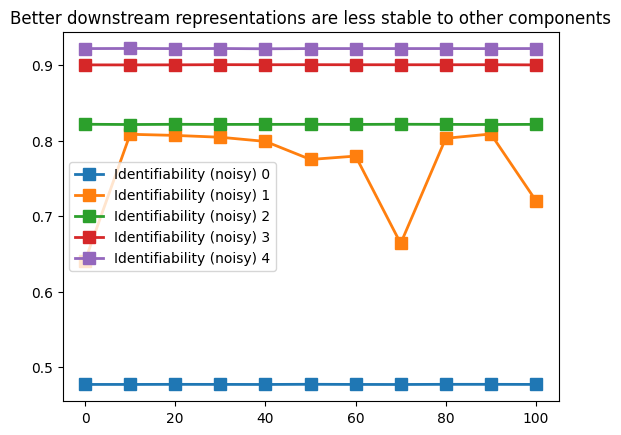

In [22]:
for i in range(len(dfs)):
    df_val, df_adv = dfs[i]
    plt.plot(df_adv['epoch'], get_identifiability(df_adv), label=f'Identifiability (noisy) {i}',  marker='s', markersize=8, linewidth=2)
plt.legend()
plt.title("Better downstream representations are less stable to other components")
plt.show()

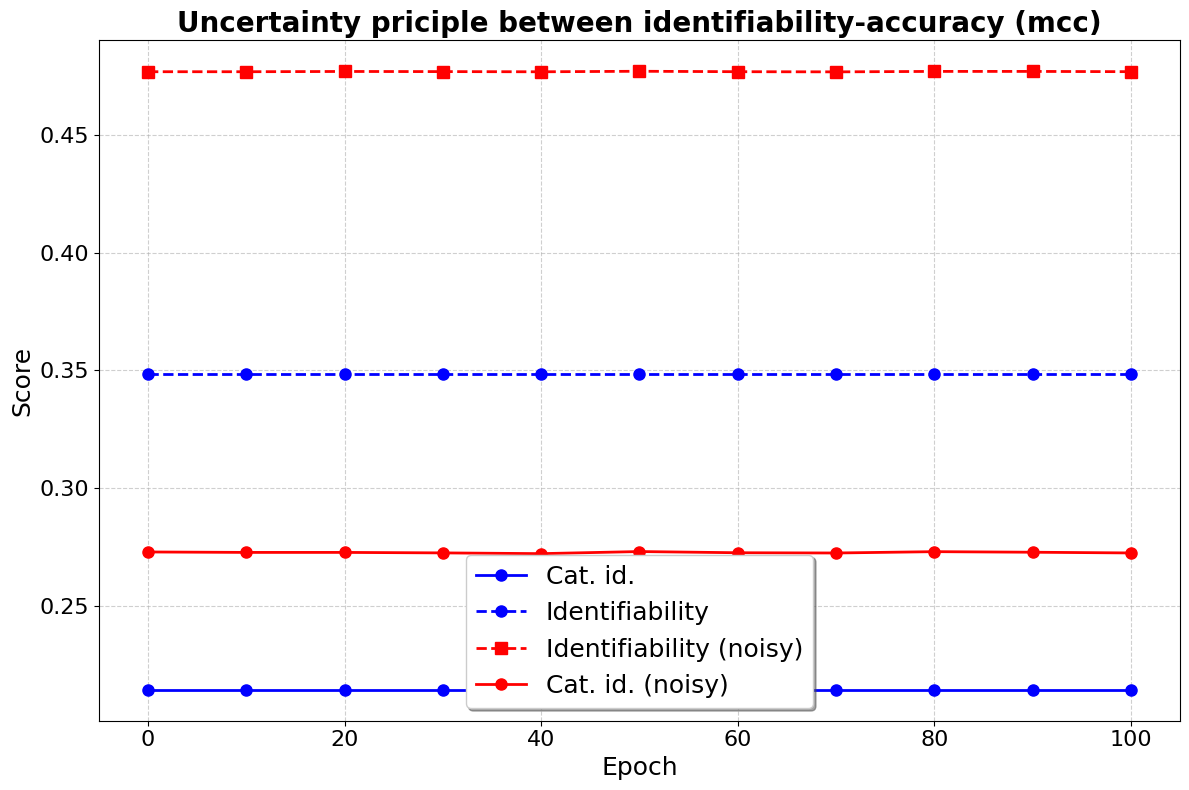

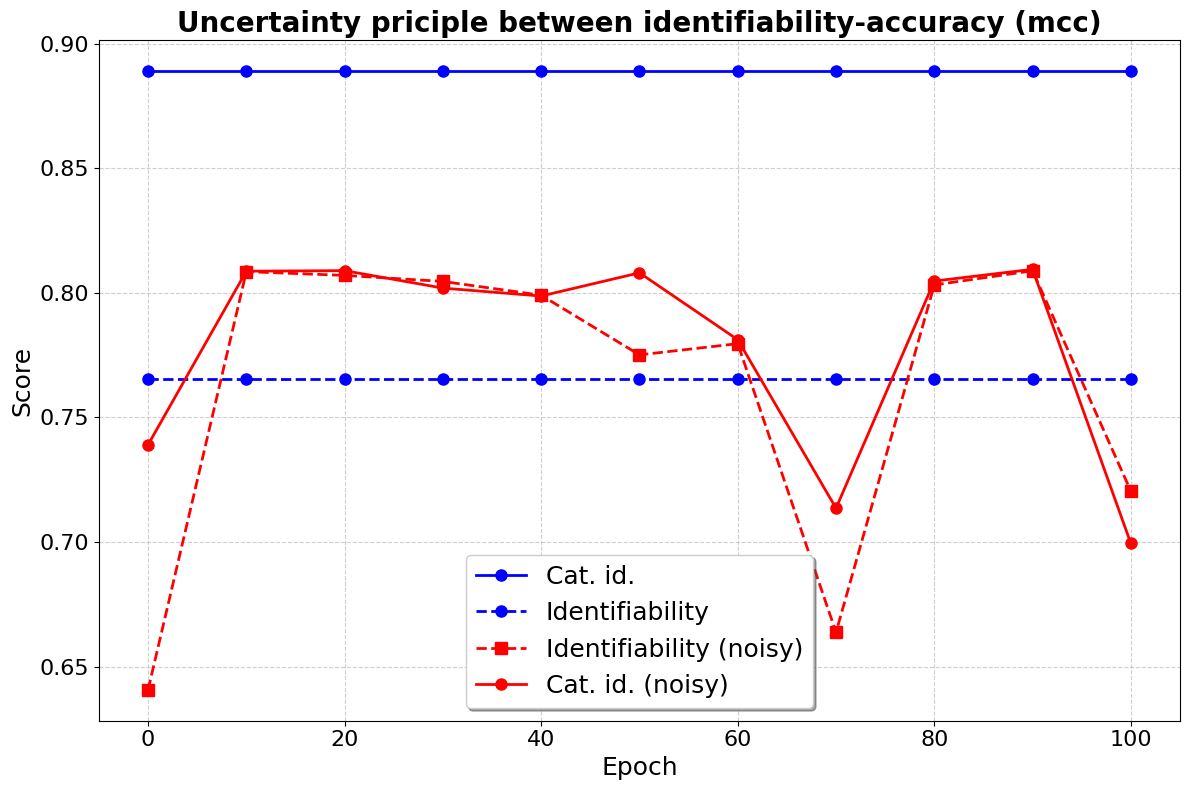

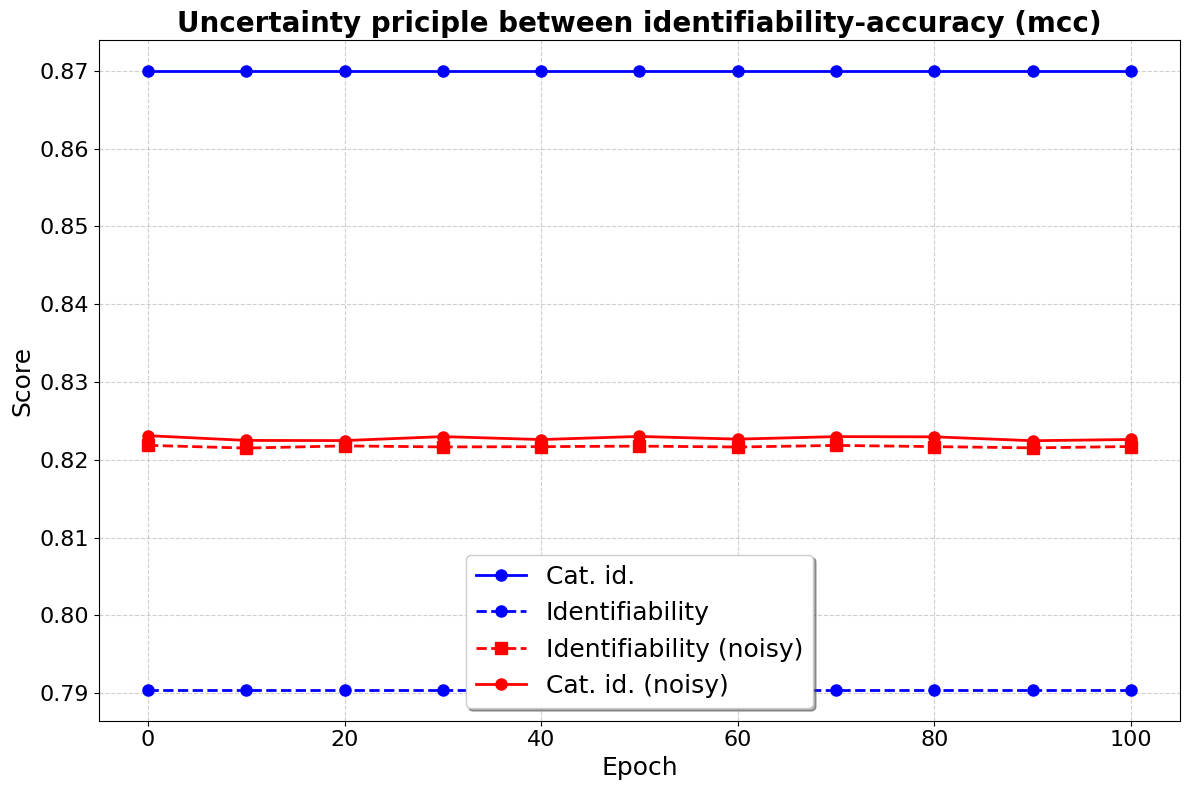

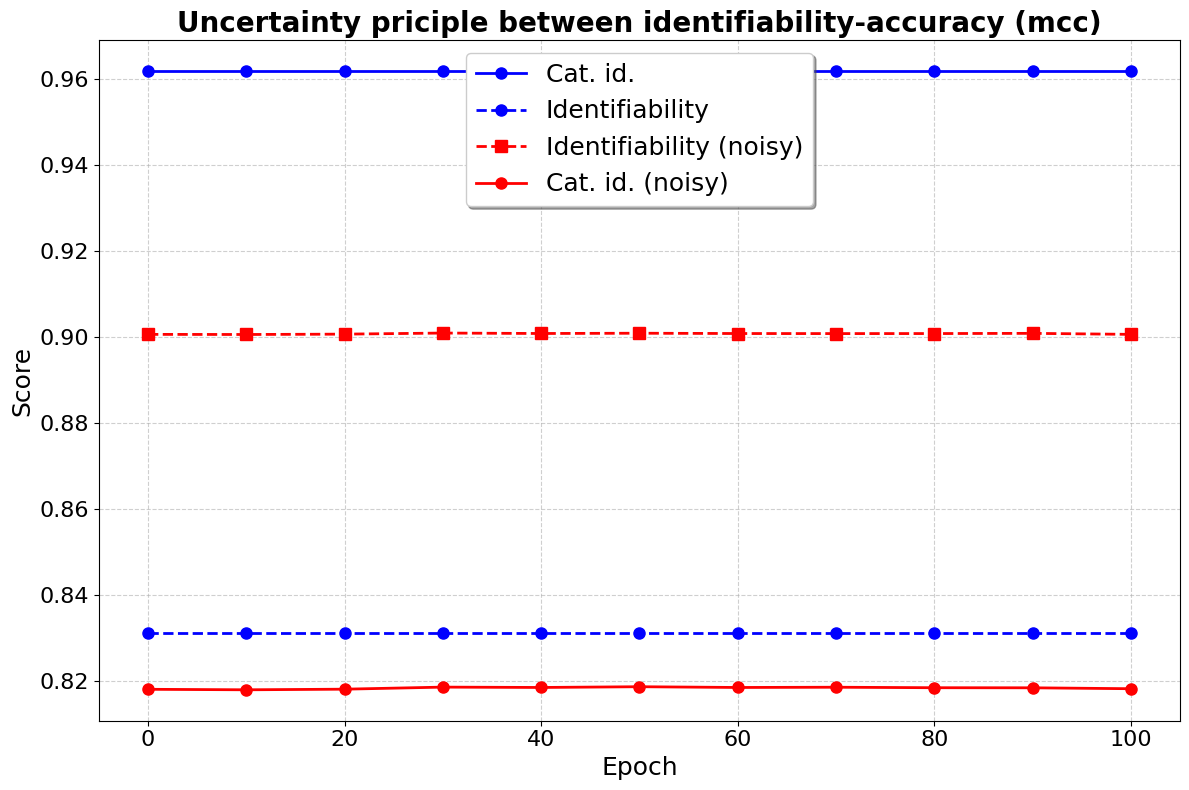

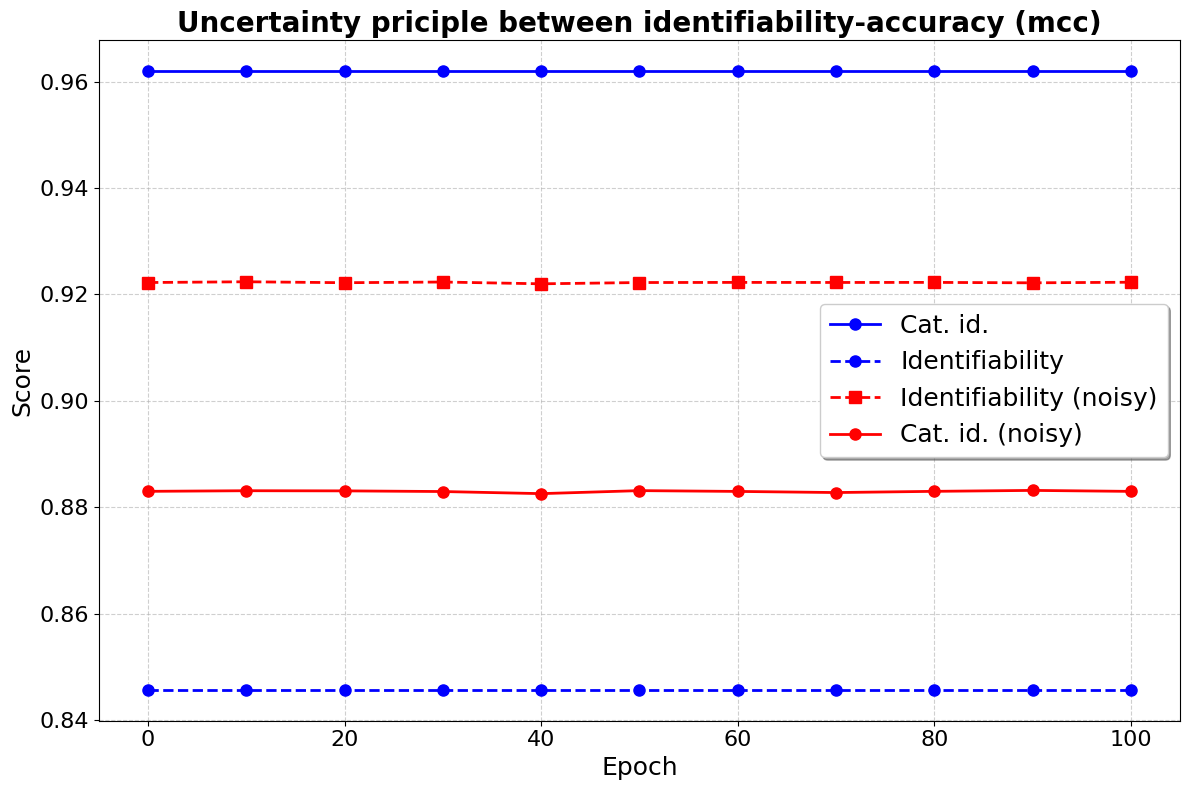

In [23]:
for i in range(len(dfs)):
    plot_train(dfs, idx=i)


In [ ]:
dfs = []
for i, p in enumerate(paths):
    print(p)
    log_path = os.path.join(p, "log_probe.txt")  
    df_val, df_adv = parse_logs(log_path)
    vals.append

In [23]:


get_identifiability(df_adv)

0     0.922230
1     0.922370
2     0.922193
3     0.922322
4     0.921987
5     0.922227
6     0.922251
7     0.922239
8     0.922253
9     0.922172
10    0.922283
dtype: float64

In [24]:
df_adv

,epoch,loss,adv_acc,shape,scale,orientation,posX,posY
0,0,0.930265,0.353819,0.882978,0.869351,0.235766,0.932234,0.951478
1,10,0.186408,0.420451,0.883092,0.869344,0.233618,0.932602,0.951415
2,20,0.089771,0.436293,0.883064,0.869139,0.232246,0.932113,0.951401
3,30,0.052616,0.450245,0.882941,0.869559,0.233371,0.932474,0.951552
4,40,0.033672,0.457795,0.882545,0.869114,0.232744,0.932064,0.951350
5,50,0.022765,0.463646,0.883111,0.869205,0.235175,0.932096,0.951473
6,60,0.016088,0.473145,0.882962,0.869204,0.234297,0.932362,0.951430
7,70,0.011831,0.485284,0.882751,0.869180,0.234090,0.932419,0.951548
8,80,0.009042,0.484759,0.882978,0.869910,0.234489,0.932301,0.951481
9,90,0.007152,0.490017,0.883153,0.869085,0.234474,0.932034,0.951329
